# Absolute-magnitude cuts and survey volume

Prompted by Doubrawa et al. 2026, *SCALE II: PZWav vs redMaPPer identification of eRosita groups* ([arXiv:2607.02706](https://arxiv.org/abs/2607.02706)), §4.3:
> "the total number of detected systems increases with the effective survey volume associated with brighter absolute-magnitude limits"

**Take-home.** A brighter absolute-magnitude cut throws away galaxies per unit volume, but it also lets you build a *complete* sample out to a larger redshift. The volume gain beats the density loss unless the luminosity function is very steep ($\alpha<-2.5$) or the cut is near $M^*$. For clusters it is the same trade-off, one level up: a brighter cut raises the minimum detectable halo mass, but the halo abundance falls more slowly than the volume grows.

Requirements: `numpy scipy matplotlib astropy colossus`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from astropy.cosmology import FlatLambdaCDM
from colossus.cosmology import cosmology as cc
from colossus.lss import mass_function

# Paper's cosmology for distances; colossus (Planck18) only for the halo mass function
cosmo = FlatLambdaCDM(H0=70, Om0=0.3); h = 0.7
cc.setCosmology('planck18')

cuts = [-18.5, -19.0, -19.5, -20.0]   # M_r limits used in the paper
zpap = [0.13, 0.15, 0.20, 0.25]       # quoted volume-limit redshifts
zmin = 0.08                           # paper's lower redshift bound
cols = ['#2a78d6', '#eb6834', '#1baf7a', '#4a3aa7']

plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': .25, 'grid.linewidth': .6})
DM = lambda z: cosmo.distmod(z).value

## 1. An $M$ cut is a $z$-dependent $m$ cut

$$m = M + \mu(z) + K(z), \qquad \mu = 5\log_{10}(d_L/\mathrm{Mpc}) + 25$$

At each redshift, $M<M_\mathrm{lim}$ is the same as $m < M_\mathrm{lim} + \mu(z) + K(z)$. That cut gets fainter as $z$ increases. The paper's Eq. 2 has no K-correction, and neither does this notebook.

The survey itself has a fixed apparent limit $m_\mathrm{lim}$. The sample is complete (volume-limited) only while the sliding cut is brighter than $m_\mathrm{lim}$:

$$\mu(z_\mathrm{max}) = m_\mathrm{lim} - M_\mathrm{lim}$$

So a **brighter $M_\mathrm{lim}$ gives a larger $z_\mathrm{max}$**.

**Check on the paper.** Inverting the paper's $(M_\mathrm{lim}, z)$ pairs should give the same $r_\mathrm{lim}$ for every cut if all four samples come from one flux-limited catalogue.

In [2]:
rlims = [M + DM(z) for M, z in zip(cuts, zpap)]
print("implied r_lim per cut:", np.round(rlims, 2))
rlim = np.mean(rlims)

zg = np.linspace(0.01, 1.2, 6000)
def zmax(M):
    # redshift where M + mu(z) reaches the flux limit
    return np.interp(rlim, M + DM(zg), zg)

zmx = [zmax(M) for M in cuts]
print(f"z_max for r_lim = {rlim:.2f}:", np.round(zmx, 3))

implied r_lim per cut: [20.43 20.27 20.46 20.5 ]
z_max for r_lim = 20.41: [0.129 0.16  0.196 0.241]


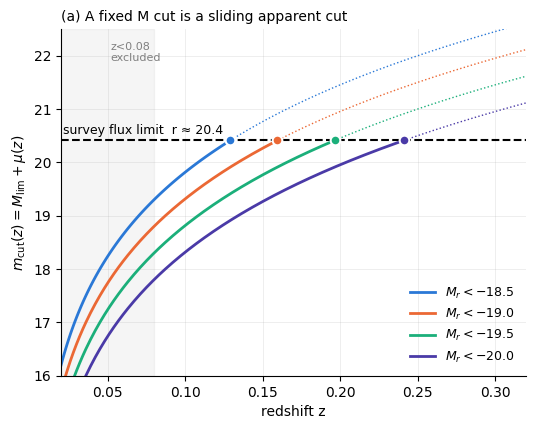

In [3]:
def panel_a(a):
    z = np.linspace(0.02, 0.32, 300)
    a.axhline(rlim, color='k', lw=1.5, ls='--')
    a.text(0.021, rlim + 0.12, f'survey flux limit  r ≈ {rlim:.1f}', fontsize=9)
    for M, c, zm in zip(cuts, cols, zmx):
        m = M + DM(z); ok = z <= zm
        a.plot(z[ok], m[ok], color=c, lw=2, label=f'$M_r<{M}$')
        a.plot(z[~ok], m[~ok], color=c, lw=1, ls=':')
        a.plot(zm, rlim, 'o', color=c, ms=7, mec='w', mew=1.5)
    a.axvspan(0, zmin, color='gray', alpha=.08)
    a.text(0.052, 21.9, 'z<0.08\nexcluded', fontsize=8, color='gray')
    a.set(xlim=(0.02, 0.32), ylim=(16, 22.5), xlabel='redshift z',
          ylabel=r'$m_{\rm cut}(z)=M_{\rm lim}+\mu(z)$')
    a.set_title('(a) A fixed M cut is a sliding apparent cut', loc='left', fontsize=10)
    a.legend(frameon=False, loc='lower right', fontsize=9)

fig, a = plt.subplots(figsize=(6, 4.5)); panel_a(a); plt.show()

## 2. Counts: density × volume

$$N = n(<M_\mathrm{lim})\; V\!\left(z_\mathrm{min}<z<z_\mathrm{max}(M_\mathrm{lim})\right)$$

**Faint-end scaling (Euclidean).** Here $n(<L)\propto L^{\alpha+1}$ and $V\propto d_\mathrm{max}^3\propto L_\mathrm{lim}^{3/2}$, so

$$N \propto L_\mathrm{lim}^{\alpha+5/2}$$

- N increases with a brighter cut whenever $\alpha>-2.5$. Galaxies have $\alpha\approx-1$, so $N\propto L^{1.5}$.
- The turnover comes from the exponential cutoff near $M^*$.
- At higher $z$, cosmology (comoving volume grows slower than $d^3$) and K-corrections soften the scaling. A fixed $z_\mathrm{min}$ amplifies it instead, because the shell volume grows faster than $V(<z_\mathrm{max})$.

The luminosity function used here is Blanton et al. 2003 (r band, $z=0.1$), converted to $h=0.7$.

In [4]:
Ms = -20.44 + 5*np.log10(h); al = -1.05; phis = 1.49e-2 * h**3   # Blanton+03 r-band

def ncum(M):
    # cumulative Schechter density n(<M) [Mpc^-3]
    x = 10**(-0.4*(M - Ms))
    return phis * quad(lambda L: L**al * np.exp(-L), x, 50)[0]

Vsh = lambda z1, z2: (cosmo.comoving_volume(z2) - cosmo.comoving_volume(z1)).value
ref = (ncum(-18.5), Vsh(zmin, zmax(-18.5)))

print(f"{'cut':>6} {'z_max':>6} {'n(<M)':>7} {'V':>6} {'n×V':>6}   (relative to M_r<-18.5)")
for M, zm in zip(cuts, zmx):
    rn, rv = ncum(M)/ref[0], Vsh(zmin, zm)/ref[1]
    print(f"{M:6.1f} {zm:6.3f} {rn:7.2f} {rv:6.2f} {rn*rv:6.2f}")

   cut  z_max   n(<M)      V    n×V   (relative to M_r<-18.5)
 -18.5  0.129    1.00   1.00   1.00
 -19.0  0.160    0.78   2.12   1.66
 -19.5  0.196    0.58   4.11   2.39
 -20.0  0.241    0.40   7.61   3.06


n×V peaks at M_lim ≈ -20.6  (M* = -21.21)


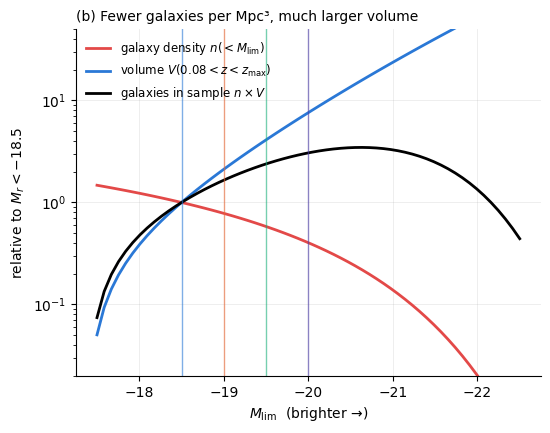

In [5]:
Mgrid = np.linspace(-17.5, -22.5, 60)
n = np.array([ncum(M) for M in Mgrid])
V = np.array([Vsh(zmin, max(zmax(M), zmin)) for M in Mgrid])
print(f"n×V peaks at M_lim ≈ {Mgrid[np.argmax(n*V)]:.1f}  (M* = {Ms:.2f})")

def panel_b(a):
    a.plot(Mgrid, n/ref[0], color='#e34948', lw=2, label=r'galaxy density $n(<M_{\rm lim})$')
    a.plot(Mgrid, V/ref[1], color='#2a78d6', lw=2, label=r'volume $V(0.08<z<z_{\rm max})$')
    a.plot(Mgrid, n*V/(ref[0]*ref[1]), color='k', lw=2, label=r'galaxies in sample $n\times V$')
    for M, c in zip(cuts, cols): a.axvline(M, color=c, lw=1, alpha=.6)
    a.set_yscale('log'); a.invert_xaxis(); a.set_ylim(0.02, 50)
    a.set(xlabel=r'$M_{\rm lim}$  (brighter →)', ylabel=r'relative to $M_r<-18.5$')
    a.set_title('(b) Fewer galaxies per Mpc³, much larger volume', loc='left', fontsize=10)
    a.legend(frameon=False, fontsize=8.5, loc='upper left')

fig, a = plt.subplots(figsize=(6, 4.5)); panel_b(a); plt.show()

## 3. Why it carries over to groups and clusters

- **Detection needs members.** A system is detected only with ≥ $\lambda_\mathrm{min}$ members brighter than the cut, so richness at fixed mass drops with a brighter cut.
- **Richness at fixed mass, from the paper.** The paper's own λ thresholds at $M_{200c}=10^{14}\,M_\odot$ are 25, 19, 15, 10 for the four cuts. With $\lambda\propto M$ and $\lambda_\mathrm{min}$ fixed so that $M_\mathrm{min}(-18.5)=2.3\times10^{13}\,M_\odot$ (the paper's quoted floor), $M_\mathrm{min}$ rises with the cut.
- **Abundance loss is smaller than the volume gain.** The halo abundance above $M_\mathrm{min}$ (Tinker08) drops more slowly than the volume grows.

**Toy model:** $N \propto \int dV\, n_h(>M_\mathrm{min})$.

In [6]:
lam14 = np.array([25, 19, 15, 10])        # paper: richness at M200c = 1e14 for each cut
Mmin_opt = 2.3e13 * 25 / lam14            # lambda ∝ M, fixed lambda_min
print("M_min [1e13 Msun]:", np.round(Mmin_opt/1e13, 2))

def nh_gt(Mmin, z):
    # comoving density of halos above Mmin [Msun], Mpc^-3 (Tinker08, M200c)
    Mh = np.logspace(np.log10(Mmin), 15.8, 200) * h                     # Msun/h
    dn = mass_function.massFunction(Mh, z, mdef='200c', model='tinker08',
                                    q_out='dndlnM') * h**3
    return np.trapezoid(dn, np.log(Mh))

def Mmin_X(z, flim=5e-14):
    # rough eRASS1-like X-ray mass limit (Leauthaud+10 L_X–M, no K-correction)
    Ez = cosmo.efunc(z); dl = cosmo.luminosity_distance(z).to('cm').value
    L = flim * 4*np.pi * dl**2
    return 2e13/0.72 * (L/Ez/10**42.7)**0.66 / Ez

def Ncl(i, xray=False):
    zz = np.linspace(zmin, zmx[i], 25)
    dV = np.gradient(cosmo.comoving_volume(zz).value, zz)
    f = [nh_gt(max(Mmin_opt[i], Mmin_X(z) if xray else 0), z) for z in zz]
    return np.trapezoid(np.array(f) * dV, zz)

No = np.array([Ncl(i) for i in range(4)])
Nx = np.array([Ncl(i, True) for i in range(4)])
paper = np.cumprod([1, 1.4, 1.5, 1.3])
print("toy model (optical only):", np.round(No/No[0], 2))
print("toy model (+ X-ray limit):", np.round(Nx/Nx[0], 2))
print("paper, matched systems  :", np.round(paper, 2))
print("X-ray M_min at z = 0.08, 0.13, 0.20, 0.25:",
      [f"{Mmin_X(z):.1e}" for z in [0.08, 0.13, 0.2, 0.25]])

M_min [1e13 Msun]: [2.3  3.03 3.83 5.75]
toy model (optical only): [1.   1.51 2.14 2.24]
toy model (+ X-ray limit): [1.   1.51 2.14 2.24]
paper, matched systems  : [1.   1.4  2.1  2.73]
X-ray M_min at z = 0.08, 0.13, 0.20, 0.25: ['7.7e+12', '1.5e+13', '2.6e+13', '3.4e+13']


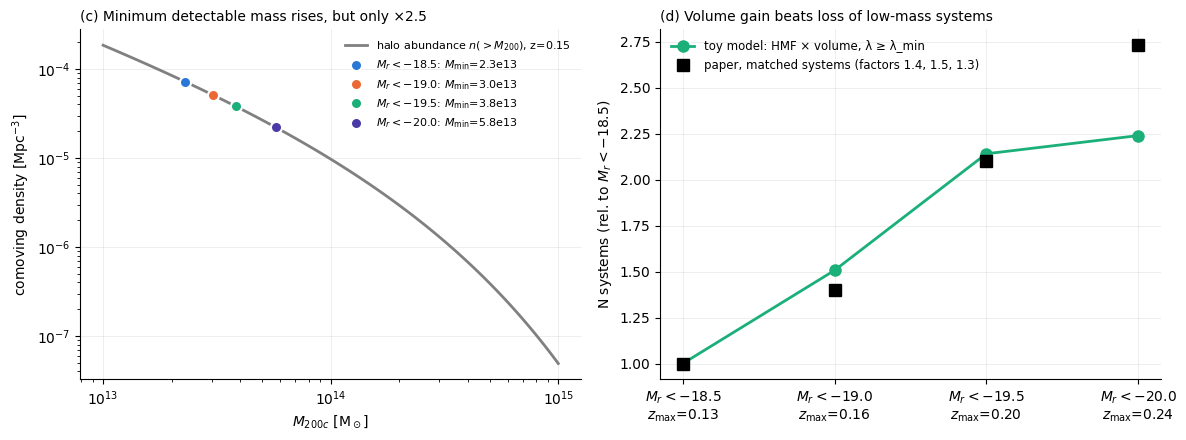

In [7]:
def panel_c(a):
    Mh = np.logspace(13, 15, 100)
    a.loglog(Mh, [nh_gt(m, 0.15) for m in Mh], color='gray', lw=2,
             label=r'halo abundance $n(>M_{200})$, z=0.15')
    for m, c, M in zip(Mmin_opt, cols, cuts):
        a.plot(m, nh_gt(m, 0.15), 'o', color=c, ms=8, mec='w', mew=1.5,
               label=rf'$M_r<{M}$: $M_{{\min}}$={m/1e13:.1f}e13')
    a.set(xlabel=r'$M_{200c}$ [M$_\odot$]', ylabel=r'comoving density [Mpc$^{-3}$]')
    a.set_title('(c) Minimum detectable mass rises, but only ×2.5', loc='left', fontsize=10)
    a.legend(frameon=False, fontsize=8)

def panel_d(a):
    x = np.arange(4)
    a.plot(x, No/No[0], '-o', color='#1baf7a', lw=2, ms=8, label=r'toy model: HMF × volume, λ ≥ λ_min')
    a.plot(x, paper, 's', color='k', ms=8, label='paper, matched systems (factors 1.4, 1.5, 1.3)')
    a.set_xticks(x, [f'$M_r<{M}$\n$z_{{\\max}}$={zm:.2f}' for M, zm in zip(cuts, zmx)])
    a.set(ylabel=r'N systems (rel. to $M_r<-18.5$)')
    a.set_title('(d) Volume gain beats loss of low-mass systems', loc='left', fontsize=10)
    a.legend(frameon=False, fontsize=8.5, loc='upper left')

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5)); panel_c(ax[0]); panel_d(ax[1]); plt.tight_layout(); plt.show()

**Result.** The toy model gives about 1 : 1.5 : 2.1 : 2.2. The paper measures 1 : 1.4 : 2.1 : 2.7.

**How the mass mix changes.** Low-mass groups are lost at low z, and massive clusters are gained at high z. This matches the paper's statements that brighter cuts favour massive systems and extend the redshift range, and why its Fig. 3 cluster fraction behaves differently from its group fraction.

### Caveats of the toy model
- λ ∝ M, fixed λ_min, no scatter, no photo-z errors, no K-corrections, no purity weighting.
- The eRASS1-like X-ray flux limit never binds: $M_\mathrm{min,X}\le3.4\times10^{13}$ up to z = 0.25, below the optical threshold. Both model versions above are therefore identical.
- The underprediction for −20 is plausibly the better photo-z fidelity of bright galaxies, which the paper notes itself and the model ignores.

### Open questions
- Where does $N(M_\mathrm{lim})$ peak for clusters, given the cluster LF has a brighter $M^*$ than the field?
- Is the richness–mass relation at a fixed cut constant with z? It is implicitly assumed when a single cut is used across the volume.
- How does this compare with the SDSS group catalogues cited in the paper (Kosowski+ 2025)?

## Combined figure

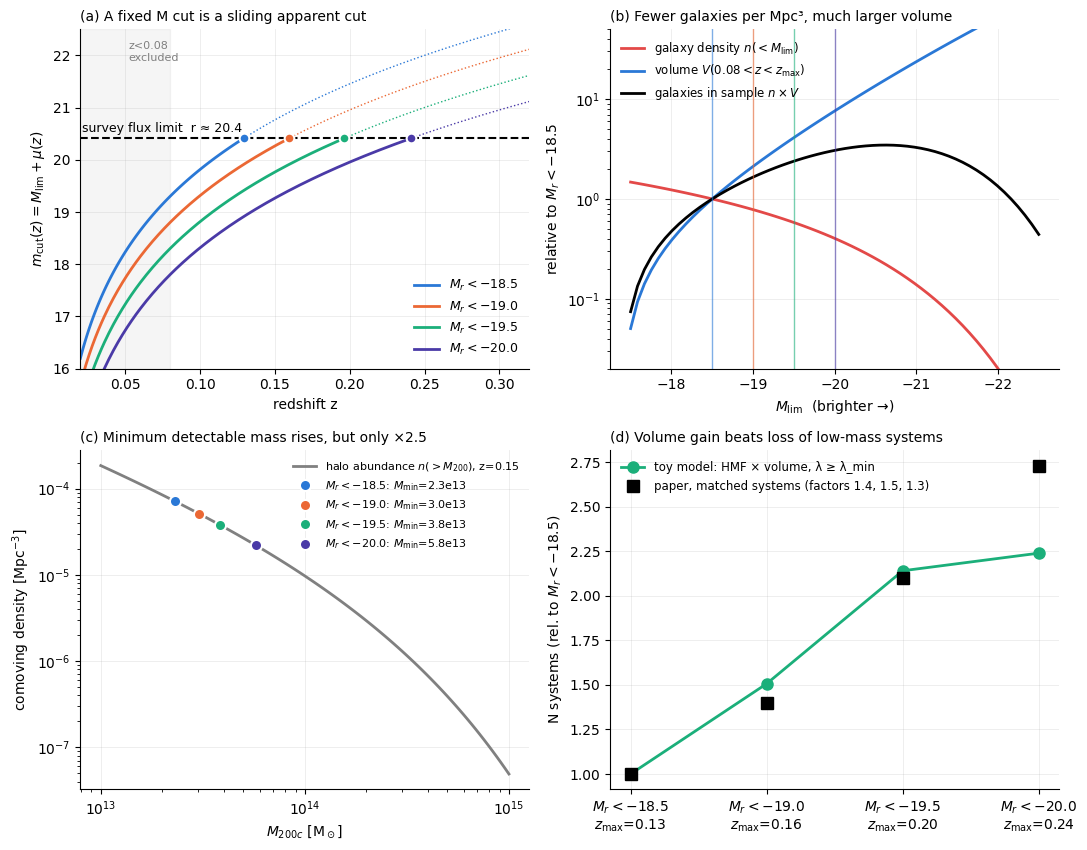

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(11, 8.6))
panel_a(ax[0, 0]); panel_b(ax[0, 1]); panel_c(ax[1, 0]); panel_d(ax[1, 1])
fig.tight_layout()
fig.savefig('abs_mag_cut_volume.png', dpi=160)
plt.show()